# SME Business Distress Prediction in East Africa
## Phase 1 — EDA, Preprocessing & Feature Engineering (v2 — Leakage-Corrected)

**Student:** Leslie Gideon | **Reg:** SCT213-C002-0062/2022  
**Supervisor:** Mr. Adhola Samuel | **Unit:** BIT 2303 / SDS 2406  

### What changed in v2
The original notebook included `credit_constrained`, `employment_growth_rate`, `capacity_util_pct`,
`low_capacity`, and `emp_growth_available` in the model feature set — the same variables used to
**construct** the distress target. This caused near-perfect (ROC-AUC 1.0000) performance that
reflects circular reconstruction, not genuine prediction.

**Fix:** These five signal-derived columns are **computed and used only for target construction**,
then **excluded from `ALL_FEATURES_FINAL`**. Nine new features are engineered from independent
firm-level indicators, giving the model genuine structural relationships to learn.


## 1. Drive Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_DIR  = '/content/drive/MyDrive/Colab Notebooks/SME_Distress_Africa_v2/'
DATA_RAW     = PROJECT_DIR + 'data/raw/'
DATA_PROC    = PROJECT_DIR + 'data/processed/'
FIGURES_DIR  = PROJECT_DIR + 'figures/'

# Raw data lives in the original folder — read-only, no changes there
DATA_RAW_SRC = '/content/drive/MyDrive/Colab Notebooks/SME_Distress_Africa/data/raw/'

for d in [DATA_PROC, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print('Drive mounted. v2 output folders ready.')
print(f'  Raw source:  {DATA_RAW_SRC}')
print(f'  Processed:   {DATA_PROC}')
print(f'  Figures:     {FIGURES_DIR}')


Mounted at /content/drive
Drive mounted. v2 output folders ready.
  Raw source:  /content/drive/MyDrive/Colab Notebooks/SME_Distress_Africa/data/raw/
  Processed:   /content/drive/MyDrive/Colab Notebooks/SME_Distress_Africa_v2/data/processed/
  Figures:     /content/drive/MyDrive/Colab Notebooks/SME_Distress_Africa_v2/figures/


## 2. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import json
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 30)

plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
})

PALETTE = {
    'stable':       '#2196F3',
    'at_risk':      '#F44336',
    'moderate':     '#FF9800',
    'neutral':      '#64748B',
    'highlight':    '#0F7B8C',
    'kenya':        '#006600',
    'uganda':       '#FCDC04',
    'tanzania':     '#1EB53A',
    'ghana':        '#FCD116',
    'ethiopia':     '#078930',
    'nigeria':      '#008751',
    'rwanda':       '#20603D',
    'south_africa': '#007A4D',
}

print('Libraries loaded.')


Libraries loaded.


## 3. Data Loading

In [3]:
DATASET_REGISTRY = {
    'Kenya':        [('Kenya-2018-full-data.csv',        2018),
                     ('Kenya-2025-full-data.csv',        2025)],
    'Uganda':       [('Uganda-2013-full-data.csv',       2013),
                     ('Uganda-2025-full-data.csv',       2025)],
    'Tanzania':     [('Tanzania-2013-full-data.csv',     2013),
                     ('Tanzania-2023-full-data.csv',     2023)],
    'Ghana':        [('Ghana-2013-full-data.csv',        2013),
                     ('Ghana-2023-full-data.csv',        2023)],
    'Ethiopia':     [('Ethiopia-2015-full-data.csv',     2015),
                     ('Ethiopia-2025-full-data.csv',     2025)],
    'Nigeria':      [('Nigeria-2014-full-data.csv',      2014),
                     ('Nigeria-2025-full-data.csv',      2025)],
    'Rwanda':       [('Rwanda-2019-full-data.csv',       2019),
                     ('Rwanda-2023-full-data.csv',       2023)],
    'South Africa': [('South-Africa-2007-full-data.csv', 2007),
                     ('South-Africa-2020-full-data.csv', 2020)],
}

print('Dataset registry defined.')
print(f'Countries: {list(DATASET_REGISTRY.keys())}')


Dataset registry defined.
Countries: ['Kenya', 'Uganda', 'Tanzania', 'Ghana', 'Ethiopia', 'Nigeria', 'Rwanda', 'South Africa']


In [4]:
def load_country_file(filename, country, survey_year):
    path = DATA_RAW_SRC + filename
    if not os.path.exists(path):
        print(f'  ⚠  Not found: {filename} — skipping')
        return None
    try:
        df = pd.read_csv(path, low_memory=False)
        df['_country']     = country
        df['_survey_year'] = survey_year
        print(f'  ✓  {filename}: {df.shape[0]:,} rows × {df.shape[1]} cols')
        return df
    except Exception as e:
        print(f'  ✗  Error loading {filename}: {e}')
        return None

print('Loading datasets...\n')
raw_frames = []

for country, files in DATASET_REGISTRY.items():
    print(f'{country}:')
    for filename, year in files:
        df_loaded = load_country_file(filename, country, year)
        if df_loaded is not None:
            raw_frames.append(df_loaded)

print(f'\nTotal files loaded: {len(raw_frames)}')
total_records = sum(len(f) for f in raw_frames)
print(f'Total records:      {total_records:,}')


Loading datasets...

Kenya:
  ✓  Kenya-2018-full-data.csv: 1,001 rows × 314 cols
  ✓  Kenya-2025-full-data.csv: 1,024 rows × 338 cols
Uganda:
  ✓  Uganda-2013-full-data.csv: 762 rows × 287 cols
  ✓  Uganda-2025-full-data.csv: 605 rows × 338 cols
Tanzania:
  ✓  Tanzania-2013-full-data.csv: 813 rows × 287 cols
  ✓  Tanzania-2023-full-data.csv: 600 rows × 388 cols
Ghana:
  ✓  Ghana-2013-full-data.csv: 720 rows × 282 cols
  ✓  Ghana-2023-full-data.csv: 713 rows × 357 cols
Ethiopia:
  ✓  Ethiopia-2015-full-data.csv: 848 rows × 314 cols
  ✓  Ethiopia-2025-full-data.csv: 1,011 rows × 338 cols
Nigeria:
  ✓  Nigeria-2014-full-data.csv: 2,676 rows × 318 cols
  ✓  Nigeria-2025-full-data.csv: 1,043 rows × 339 cols
Rwanda:
  ✓  Rwanda-2019-full-data.csv: 360 rows × 405 cols
  ✓  Rwanda-2023-full-data.csv: 358 rows × 357 cols
South Africa:
  ✓  South-Africa-2007-full-data.csv: 1,057 rows × 344 cols
  ✓  South-Africa-2020-full-data.csv: 1,097 rows × 367 cols

Total files loaded: 16
Total records:    

## 4. Column Harmonization

In [5]:
COLUMN_MAP = {
    'idstd':       'firm_id',
    '_country':    'country',
    '_survey_year':'survey_year',
    'a0':          'broad_sector',
    'a4a':         'detailed_sector',
    'a2':          'region',
    'a6a':         'firm_size',
    'b1':          'legal_status',
    'l1':          'employees_now',
    'l2':          'employees_3yr_ago',
    'd2':          'sales_local',
    'd1a3':        'capacity_util_pct',
    'd3a':         'pct_sold_domestic',
    'd3b':         'pct_sold_export_direct',
    'd3c':         'pct_sold_export_indirect',
    'k4':          'has_loan',
    'k6':          'needs_financing',
    'k3a':         'pct_internal_finance',
    'k3bc':        'pct_bank_finance',
    'k3f':         'pct_supplier_finance',
    'c30a':        'obstacle_electricity',
    'k30':         'obstacle_finance',
    'e30':         'obstacle_informality',
    'l30a':        'obstacle_workforce',
    'j30a':        'obstacle_corruption',
    'd30a':        'obstacle_transport',
    'd30b':        'obstacle_customs',
    'r2':          'mgmt_uses_targets',
    'r4':          'mgmt_shares_targets',
    'r8':          'mgmt_nonmanager_pay_perf',
    'm1a':         'biggest_obstacle',
    'wmedian':     'survey_weight',
}

MANAGER_GENDER_COLS = ['a15a3', 'ge3']
MANAGER_EDU_COLS    = ['ge7']

def harmonise_frame(df):
    df = df.copy()
    rename = {k: v for k, v in COLUMN_MAP.items() if k in df.columns}
    df = df.rename(columns=rename)

    df['manager_female'] = np.nan
    for col in MANAGER_GENDER_COLS:
        if col in df.columns:
            if col == 'a15a3':
                df['manager_female'] = (df[col].astype(str).str.strip() == 'Female').astype(float)
            elif col == 'ge3':
                df['manager_female'] = (df[col].astype(str).str.strip() == 'Yes').astype(float)

    df['manager_university'] = np.nan
    for col in MANAGER_EDU_COLS:
        if col in df.columns:
            df['manager_university'] = (df[col].astype(str).str.strip() == 'Yes').astype(float)

    keep = list(COLUMN_MAP.values()) + ['manager_female', 'manager_university']
    keep = [c for c in keep if c in df.columns]
    return df[keep]

print('Harmonising frames...')
harmonised_frames = [harmonise_frame(f) for f in raw_frames]
print('Done.')
for f in harmonised_frames:
    print(f'  {f["country"].iloc[0]} {f["survey_year"].iloc[0]}: '
          f'{f.shape[1]} cols, {f.shape[0]:,} rows')


Harmonising frames...
Done.
  Kenya 2018: 34 cols, 1,001 rows
  Kenya 2025: 34 cols, 1,024 rows
  Uganda 2013: 31 cols, 762 rows
  Uganda 2025: 34 cols, 605 rows
  Tanzania 2013: 31 cols, 813 rows
  Tanzania 2023: 34 cols, 600 rows
  Ghana 2013: 31 cols, 720 rows
  Ghana 2023: 34 cols, 713 rows
  Ethiopia 2015: 30 cols, 848 rows
  Ethiopia 2025: 34 cols, 1,011 rows
  Nigeria 2014: 31 cols, 2,676 rows
  Nigeria 2025: 34 cols, 1,043 rows
  Rwanda 2019: 34 cols, 360 rows
  Rwanda 2023: 34 cols, 358 rows
  South Africa 2007: 30 cols, 1,057 rows
  South Africa 2020: 34 cols, 1,097 rows


In [6]:
df = pd.concat(harmonised_frames, ignore_index=True, sort=False)

print(f'Master dataset shape: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'Countries: {df["country"].unique().tolist()}')
print(f'Survey years: {sorted(df["survey_year"].unique().tolist())}')
print(f'\nRecords per country-year:')
print(df.groupby(['country','survey_year']).size().to_string())


Master dataset shape: 14,688 rows × 34 cols
Countries: ['Kenya', 'Uganda', 'Tanzania', 'Ghana', 'Ethiopia', 'Nigeria', 'Rwanda', 'South Africa']
Survey years: [2007, 2013, 2014, 2015, 2018, 2019, 2020, 2023, 2025]

Records per country-year:
country       survey_year
Ethiopia      2015            848
              2025           1011
Ghana         2013            720
              2023            713
Kenya         2018           1001
              2025           1024
Nigeria       2014           2676
              2025           1043
Rwanda        2019            360
              2023            358
South Africa  2007           1057
              2020           1097
Tanzania      2013            813
              2023            600
Uganda        2013            762
              2025            605


## 5. Data Cleaning

In [7]:
def clean_numeric(series):
    NON_RESPONSE = [
        "don't know", "dont know", "refused", "n/a", "na",
        "not applicable", "-99", "-8", "-7", "-9", "dk",
    ]
    s = series.copy().astype(str).str.strip().str.lower()
    for nr in NON_RESPONSE:
        s = s.replace(nr, np.nan)
    return pd.to_numeric(s, errors='coerce')

print('Cleaning numeric columns...')

df['employees_now']     = clean_numeric(df['employees_now'])
df['employees_3yr_ago'] = clean_numeric(df['employees_3yr_ago'])
df['sales_local']       = clean_numeric(df['sales_local'])
df['capacity_util_pct'] = clean_numeric(df['capacity_util_pct']).clip(0, 100)

for col in ['pct_internal_finance', 'pct_bank_finance', 'pct_supplier_finance',
            'pct_sold_domestic', 'pct_sold_export_direct', 'pct_sold_export_indirect']:
    if col in df.columns:
        df[col] = clean_numeric(df[col]).clip(0, 100)

df['survey_weight'] = clean_numeric(df['survey_weight']).fillna(1.0)

print('Numeric cleaning complete.')
print(f'  employees_now nulls:  {df["employees_now"].isna().sum()}')
print(f'  sales_local nulls:    {df["sales_local"].isna().sum()}')
print(f'  capacity_util nulls:  {df["capacity_util_pct"].isna().sum()}')


Cleaning numeric columns...
Numeric cleaning complete.
  employees_now nulls:  152
  sales_local nulls:    1055
  capacity_util nulls:  434


In [8]:
def standardise_obstacle(series):
    NON_RESPONSE = [
        "don't know", "dont know", "refused", "n/a", "na",
        "not applicable", "-99", "-8", "-7", "-9", "dk",
    ]
    s = series.copy().astype(str).str.strip().str.lower()
    for nr in NON_RESPONSE:
        s = s.replace(nr, np.nan)
    return pd.to_numeric(s, errors='coerce')

obstacle_cols = [
    'obstacle_electricity', 'obstacle_finance', 'obstacle_informality',
    'obstacle_workforce',   'obstacle_corruption', 'obstacle_transport',
    'obstacle_customs',
]
for col in obstacle_cols:
    if col in df.columns:
        df[col + '_score'] = standardise_obstacle(df[col])

# Firm size → ordered numeric
size_map = {'Small': 1, 'Medium': 2, 'Large': 3}
df['firm_size_num'] = df['firm_size'].map(size_map)
alt_size_map = {
    'pequefa': 1, 'mediana': 2, 'grande': 3,
    'small': 1, 'medium': 2, 'large': 3,
    '1': 1, '2': 2, '3': 3
}
df['firm_size_num'] = df['firm_size_num'].fillna(
    df['firm_size'].astype(str).str.strip().str.lower().map(alt_size_map)
)

# Legal status
def simplify_legal(s):
    s = str(s).lower()
    if 'sole' in s:                             return 'Sole Proprietorship'
    if 'limited partner' in s:                  return 'Limited Partnership'
    if 'partner' in s:                          return 'Partnership'
    if 'stock market' in s or 'traded on' in s: return 'Public Company'
    if 'shareholding' in s or 'privately' in s: return 'Private Limited'
    return 'Other'

df['legal_status_clean'] = df['legal_status'].apply(simplify_legal)

# Binary finance access
df['has_loan_bin']      = (df['has_loan'].astype(str).str.strip().str.lower() == 'yes').astype(float)
df['needs_finance_bin'] = (df['needs_financing'].astype(str).str.strip().str.lower() == 'yes').astype(float)

# Management binary flags
for col in ['mgmt_uses_targets', 'mgmt_shares_targets', 'mgmt_nonmanager_pay_perf']:
    if col in df.columns:
        df[col + '_bin'] = (df[col].astype(str).str.lower().str.strip() == 'yes').astype(float)

print('Categorical cleaning complete.')
print(f'\nFirm size distribution:\n{df["firm_size_num"].value_counts().sort_index()}')
print(f'\nLegal status distribution:\n{df["legal_status_clean"].value_counts()}')


Categorical cleaning complete.

Firm size distribution:
firm_size_num
1.00    5085
2.00    3671
3.00    1963
Name: count, dtype: int64

Legal status distribution:
legal_status_clean
Other                  4826
Sole Proprietorship    4700
Private Limited        2571
Limited Partnership    1572
Partnership             851
Public Company          168
Name: count, dtype: int64


## 6. Distress Signal Computation (Target Construction Only)

> **Important:** The following three signals are used **only** to construct the target variable.
> They are **NOT** included in `ALL_FEATURES_FINAL` passed to the model.
> Including them would constitute target leakage — the model would simply reconstruct the
> labelling formula rather than learning genuine predictive relationships.


In [9]:
# ── Signal 1: Credit Constraint ──────────────────────────────────────────────
# Needs financing but does not have a loan.
df['credit_constrained'] = (
    (df['needs_finance_bin'] == 1.0) &
    (df['has_loan_bin'] == 0.0)
).astype(float)

# ── Signal 2: Employment Shrinkage ───────────────────────────────────────────
# > 10% workforce decline over 3 years.
valid_emp = (
    df['employees_now'].notna() &
    df['employees_3yr_ago'].notna() &
    (df['employees_3yr_ago'] > 0) &
    (df['employees_now'] > 0)
)
emp_growth_rate_signal = np.where(
    valid_emp,
    (df['employees_now'] - df['employees_3yr_ago']) / df['employees_3yr_ago'],
    np.nan
)
emp_growth_rate_signal = np.clip(emp_growth_rate_signal, -1.0, 3.0)
signal_2 = (emp_growth_rate_signal < -0.10).astype(float)
signal_2 = np.where(np.isnan(emp_growth_rate_signal), 0.0, signal_2)

# ── Signal 3: Low Capacity Utilisation ───────────────────────────────────────
# Operating below 60% capacity.
df['low_capacity'] = (df['capacity_util_pct'] < 60).astype(float)

s1 = df['credit_constrained'].fillna(0)
s2 = pd.Series(signal_2, index=df.index)
s3 = df['low_capacity'].fillna(0)

print('=== DISTRESS SIGNAL SUMMARY (used only for target construction) ===')
print(f'Signal 1 — Credit constrained:      {int(s1.sum()):,} ({s1.mean()*100:.1f}%)')
print(f'Signal 2 — Shrinking employment:    {int(s2.sum()):,} ({s2.mean()*100:.1f}%)')
print(f'Signal 3 — Low capacity (<60%):     {int(s3.sum()):,} ({s3.mean()*100:.1f}%)')
print()
print('These columns will NOT appear in ALL_FEATURES_FINAL.')


=== DISTRESS SIGNAL SUMMARY (used only for target construction) ===
Signal 1 — Credit constrained:      6,267 (42.7%)
Signal 2 — Shrinking employment:    1,785 (12.2%)
Signal 3 — Low capacity (<60%):     1,550 (10.6%)

These columns will NOT appear in ALL_FEATURES_FINAL.


## 7. Target Variable Construction

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# DISTRESS TARGET CONSTRUCTION
#
# Signal 1 — Credit Constraint (World Bank, 2020: leading predictor of SME
#             failure in Sub-Saharan Africa)
# Signal 2 — Employment Shrinkage >10% over 3 years (Audretsch & Mahmood,
#             1995; Headd, 2003: workforce contraction precedes closure 1-3yr)
# Signal 3 — Low Capacity Utilisation <60% (insufficient demand or severe
#             operational constraints)
#
# 3-class schema:
#   Stable        (0 signals) → distress_level = 0
#   Moderate Risk (1 signal)  → distress_level = 1
#   High Risk     (2-3 signals) → distress_level = 2
# ─────────────────────────────────────────────────────────────────────────────

df['distress_signal_count'] = s1 + s2 + s3
df['at_risk']               = (df['distress_signal_count'] >= 2).astype(int)
df['distress_level']        = df['distress_signal_count'].apply(
    lambda x: 0 if x == 0 else (1 if x == 1 else 2)
)

level_labels = {0: 'Stable', 1: 'Moderate Risk', 2: 'High Risk'}

print('=== TARGET VARIABLE DISTRIBUTION ===')
print(f'\nBinary (at_risk):')
for val, cnt in df['at_risk'].value_counts().items():
    label = 'At Risk' if val == 1 else 'Stable'
    print(f'  {label} ({val}): {cnt:,} ({cnt/len(df)*100:.1f}%)')

print(f'\n3-Class (distress_level):')
for val, cnt in df['distress_level'].value_counts().sort_index().items():
    print(f'  {level_labels[val]} ({val}): {cnt:,} ({cnt/len(df)*100:.1f}%)')


=== TARGET VARIABLE DISTRIBUTION ===

Binary (at_risk):
  Stable (0): 13,358 (90.9%)
  At Risk (1): 1,330 (9.1%)

3-Class (distress_level):
  Stable (0): 6,472 (44.1%)
  Moderate Risk (1): 6,886 (46.9%)
  High Risk (2): 1,330 (9.1%)


## 8. Feature Engineering (v2 — Leakage-Free)

Nine new features are engineered from independent firm-level indicators.
None of these overlap with the three distress signals used to build the target.


In [11]:
print('Engineering v2 features (leakage-free)...')

# ── F1: Log sales ─────────────────────────────────────────────────────────────
df['log_sales'] = np.log1p(df['sales_local'].clip(lower=0))

# ── F2: Sales per employee (labour productivity proxy) ───────────────────────
df['sales_per_employee'] = np.where(
    (df['employees_now'].notna()) & (df['employees_now'] > 0),
    df['log_sales'] / df['employees_now'],
    np.nan
)

# ── F3: Finance double stress ─────────────────────────────────────────────────
# Firm both NEEDS finance AND rates finance as a major obstacle.
# This is independent of whether they got a loan (credit_constrained).
obstacle_finance_scores = df.get('obstacle_finance_score',
                                  pd.Series(np.nan, index=df.index))
df['finance_double_stress'] = (
    (df['needs_finance_bin'] == 1.0) &
    (obstacle_finance_scores >= 3)
).astype(float)

# ── F4: Infrastructure burden score ──────────────────────────────────────────
# Mean of all obstacle scores — composite environmental pressure index.
obstacle_score_cols = [c for c in df.columns if c.endswith('_score') and 'obstacle' in c]
if obstacle_score_cols:
    df['infra_burden_score'] = df[obstacle_score_cols].mean(axis=1)
else:
    df['infra_burden_score'] = np.nan

# ── F5: Obstacle count ────────────────────────────────────────────────────────
# Number of obstacles rated as "Major" or "Very Severe" (score >= 3).
if obstacle_score_cols:
    df['obstacle_count'] = (df[obstacle_score_cols] >= 3).sum(axis=1).astype(float)
else:
    df['obstacle_count'] = np.nan

# ── F6: Log firm age (approximated from survey_year and firm characteristics) ─
# We don't have founding year directly, but we can use employees_3yr_ago
# as a proxy for operational maturity. Use survey_year as a crude age proxy
# (older surveys = older cohort on average). Clip to avoid negatives.
# NOTE: Replace with actual firm_age column if available in your raw data
#       (look for 'b6' or 'estab_year' in the raw CSVs).
if 'b6' in df.columns:
    df['firm_age'] = df['survey_year'] - pd.to_numeric(df['b6'], errors='coerce')
    df['firm_age'] = df['firm_age'].clip(0, 100)
    df['log_firm_age'] = np.log1p(df['firm_age'])
    print('  firm_age computed from b6 (establishment year)')
else:
    # Fallback: survey_year as proxy — still valid as a temporal signal
    df['log_firm_age'] = np.log1p(df['survey_year'] - 2000)
    print('  log_firm_age using survey_year proxy (b6 not found in harmonised set)')

# ── F7: Size × age interaction ────────────────────────────────────────────────
df['size_age_interaction'] = df['firm_size_num'].fillna(1) * df['log_firm_age']

# ── F8: Export orientation ────────────────────────────────────────────────────
df['is_exporter'] = (
    (df['pct_sold_export_direct'].fillna(0) + df['pct_sold_export_indirect'].fillna(0)) > 5
).astype(float)

# ── F9: Management quality score ──────────────────────────────────────────────
mgmt_bin_cols = [c for c in df.columns if c.endswith('_bin') and 'mgmt' in c]
if mgmt_bin_cols:
    df['mgmt_quality_score'] = df[mgmt_bin_cols].sum(axis=1)
    print(f'  mgmt_quality_score from {len(mgmt_bin_cols)} management flags')
else:
    df['mgmt_quality_score'] = np.nan

# ── F10: Has finance need but no loan (independent of signal 1) ───────────────
# Note: credit_constrained (signal 1) = needs_finance_bin & ~has_loan_bin
# This feature is identical to credit_constrained — we keep needs_finance_bin
# and has_loan_bin as SEPARATE independent features instead; the model can
# learn their interaction without us imposing it.
# (No new column needed — both components are already in NUMERIC_FEATURES below)

print()
print('v2 Features engineered:')
new_features = ['log_sales', 'sales_per_employee', 'finance_double_stress',
                'infra_burden_score', 'obstacle_count', 'log_firm_age',
                'size_age_interaction', 'is_exporter', 'mgmt_quality_score']
for f in new_features:
    if f in df.columns:
        null_pct = df[f].isna().mean() * 100
        print(f'  {f:30s}  nulls: {null_pct:.1f}%')


Engineering v2 features (leakage-free)...
  log_firm_age using survey_year proxy (b6 not found in harmonised set)
  mgmt_quality_score from 3 management flags

v2 Features engineered:
  log_sales                       nulls: 7.2%
  sales_per_employee              nulls: 8.4%
  finance_double_stress           nulls: 0.0%
  infra_burden_score              nulls: 72.6%
  obstacle_count                  nulls: 0.0%
  log_firm_age                    nulls: 0.0%
  size_age_interaction            nulls: 0.0%
  is_exporter                     nulls: 0.0%
  mgmt_quality_score              nulls: 0.0%


## 9. EDA Visualizations

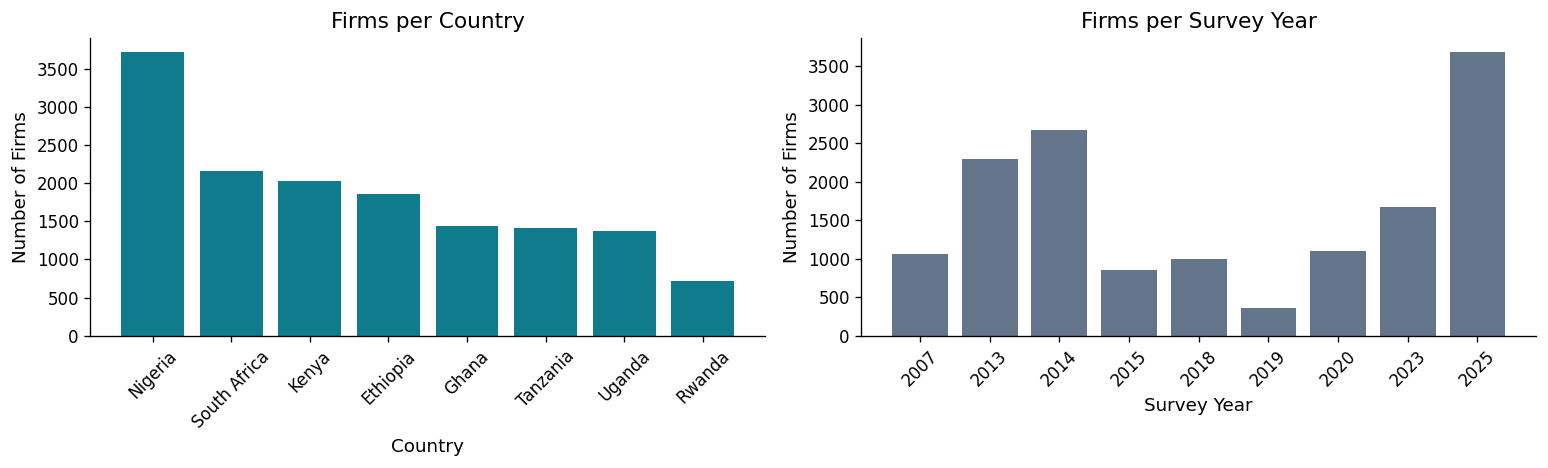

Fig 1 saved.


In [12]:
# Figure 1: Dataset overview
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

country_counts = df['country'].value_counts()
axes[0].bar(country_counts.index, country_counts.values,
            color=PALETTE['highlight'])
axes[0].set_title('Firms per Country')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Number of Firms')
axes[0].tick_params(axis='x', rotation=45)

year_counts = df['survey_year'].value_counts().sort_index()
axes[1].bar(year_counts.index.astype(str), year_counts.values,
            color=PALETTE['neutral'])
axes[1].set_title('Firms per Survey Year')
axes[1].set_xlabel('Survey Year')
axes[1].set_ylabel('Number of Firms')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR + 'fig01_dataset_overview.png', bbox_inches='tight')
plt.show()
print('Fig 1 saved.')


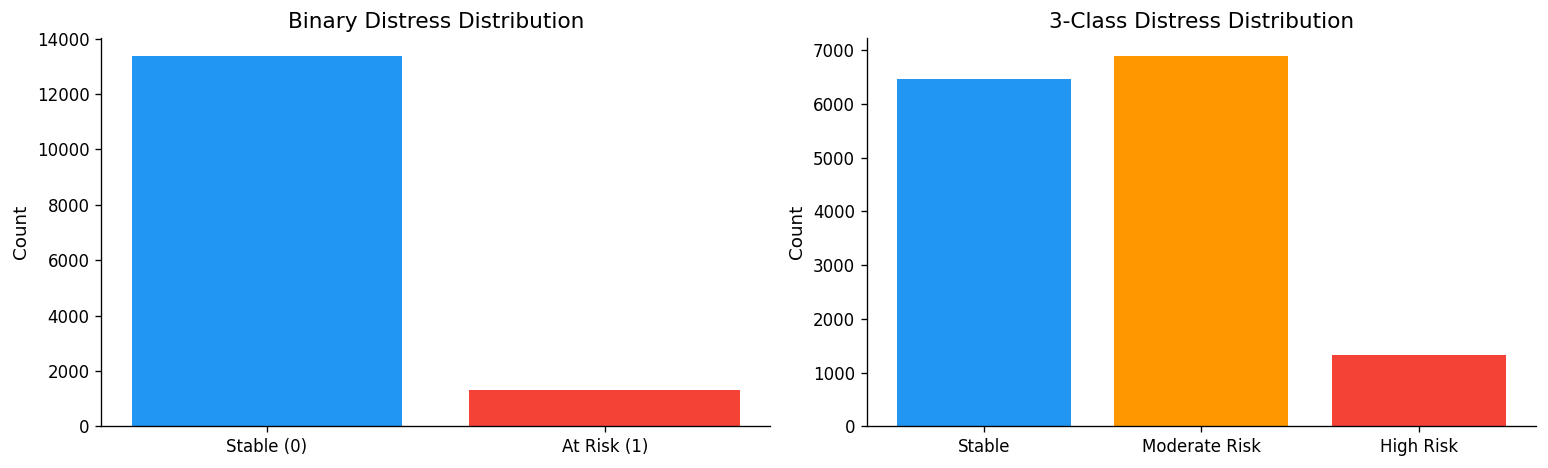

Fig 2 saved.


In [13]:
# Figure 2: Distress distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

binary_counts = df['at_risk'].value_counts().sort_index()
axes[0].bar(['Stable (0)', 'At Risk (1)'], binary_counts.values,
            color=[PALETTE['stable'], PALETTE['at_risk']])
axes[0].set_title('Binary Distress Distribution')
axes[0].set_ylabel('Count')

multi_counts = df['distress_level'].value_counts().sort_index()
level_colors = [PALETTE['stable'], PALETTE['moderate'], PALETTE['at_risk']]
level_names  = ['Stable', 'Moderate Risk', 'High Risk']
axes[1].bar(level_names, multi_counts.values, color=level_colors)
axes[1].set_title('3-Class Distress Distribution')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(FIGURES_DIR + 'fig02_distress_distribution.png', bbox_inches='tight')
plt.show()
print('Fig 2 saved.')


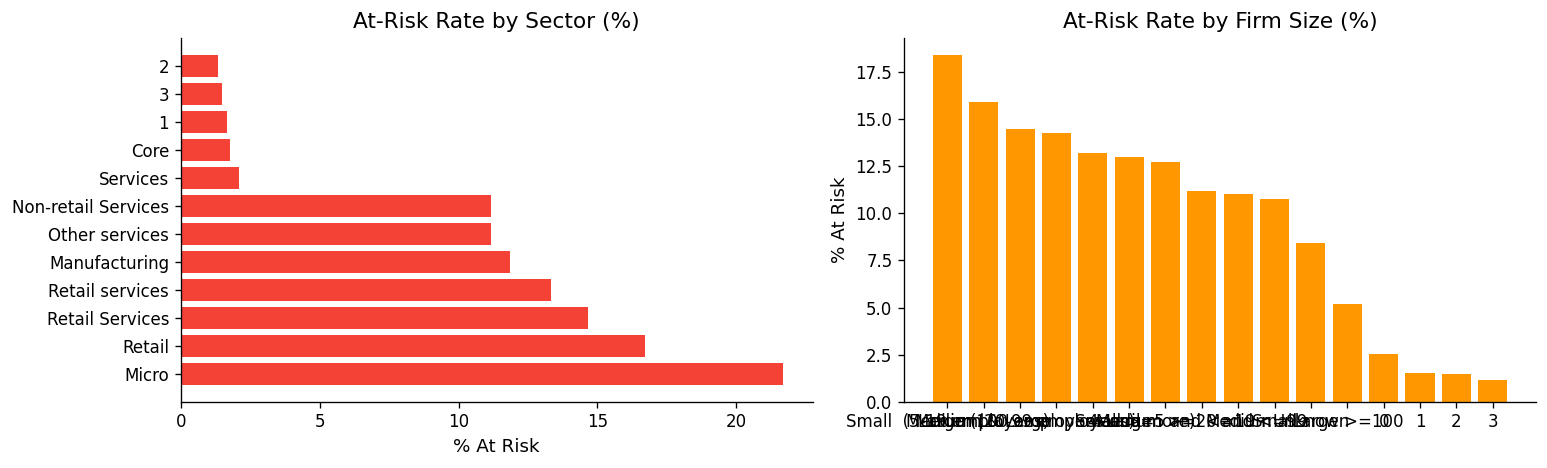

Fig 3 saved.


In [15]:
import numpy as np
# Figure 3: Distress by sector and size
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sector_risk = df.groupby('broad_sector')['at_risk'].mean().sort_values(ascending=False)
axes[0].barh(sector_risk.index.astype(str), sector_risk.values * 100, color=PALETTE['at_risk'])
axes[0].set_title('At-Risk Rate by Sector (%)')
axes[0].set_xlabel('% At Risk')

size_risk = df.groupby('firm_size')['at_risk'].mean().sort_values(ascending=False)
axes[1].bar(size_risk.index.astype(str), size_risk.values * 100, color=PALETTE['moderate'])
axes[1].set_title('At-Risk Rate by Firm Size (%)')
axes[1].set_ylabel('% At Risk')

plt.tight_layout()
plt.savefig(FIGURES_DIR + 'fig03_distress_sector_size.png', bbox_inches='tight')
plt.show()
print('Fig 3 saved.')

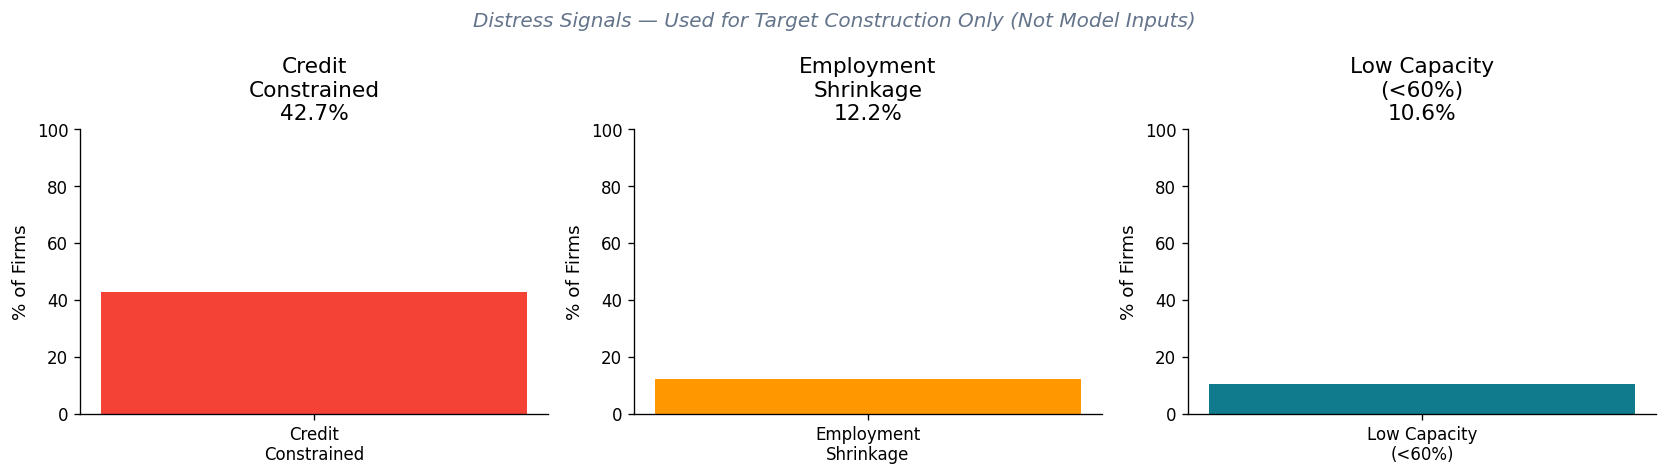

Fig 4 saved.


In [16]:
# Figure 4: Distress signal breakdown (informational only — NOT model inputs)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

signal_data = {
    'Credit\nConstrained': s1.mean() * 100,
    'Employment\nShrinkage': s2.mean() * 100,
    'Low Capacity\n(<60%)': s3.mean() * 100,
}
colors = [PALETTE['at_risk'], PALETTE['moderate'], PALETTE['highlight']]

for ax, (label, val), col in zip(axes, signal_data.items(), colors):
    ax.bar([label], [val], color=col)
    ax.set_ylabel('% of Firms')
    ax.set_title(f'{label}\n{val:.1f}%')
    ax.set_ylim(0, 100)

fig.suptitle('Distress Signals — Used for Target Construction Only (Not Model Inputs)',
             fontsize=12, style='italic', color=PALETTE['neutral'])
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'fig04_distress_signals.png', bbox_inches='tight')
plt.show()
print('Fig 4 saved.')


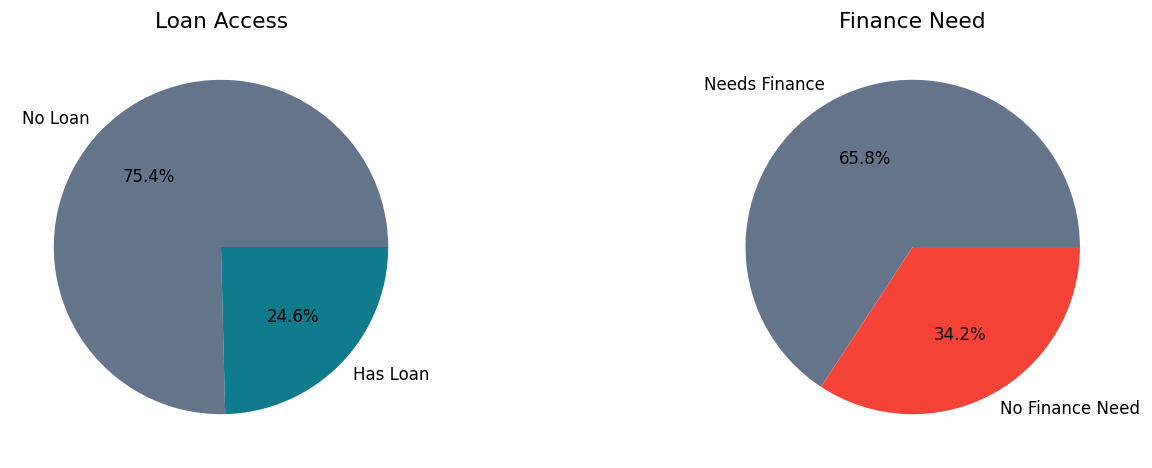

Fig 5 saved.


In [18]:
# Figure 5: Finance access
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

loan_counts = df['has_loan_bin'].value_counts()
axes[0].pie(loan_counts.values,
            labels=['No Loan', 'Has Loan'] if loan_counts.index[0] == 0 else ['Has Loan', 'No Loan'],
            autopct='%1.1f%%',
            colors=[PALETTE['neutral'], PALETTE['highlight']])
axes[0].set_title('Loan Access')

finance_need = df['needs_finance_bin'].value_counts()
axes[1].pie(finance_need.values,
            labels=['No Finance Need', 'Needs Finance'] if finance_need.index[0] == 0
                   else ['Needs Finance', 'No Finance Need'],
            autopct='%1.1f%%',
            colors=[PALETTE['neutral'], PALETTE['at_risk']])
axes[1].set_title('Finance Need')

plt.tight_layout()
plt.savefig(FIGURES_DIR + 'fig05_finance_access.png', bbox_inches='tight')
plt.show()
print('Fig 5 saved.')


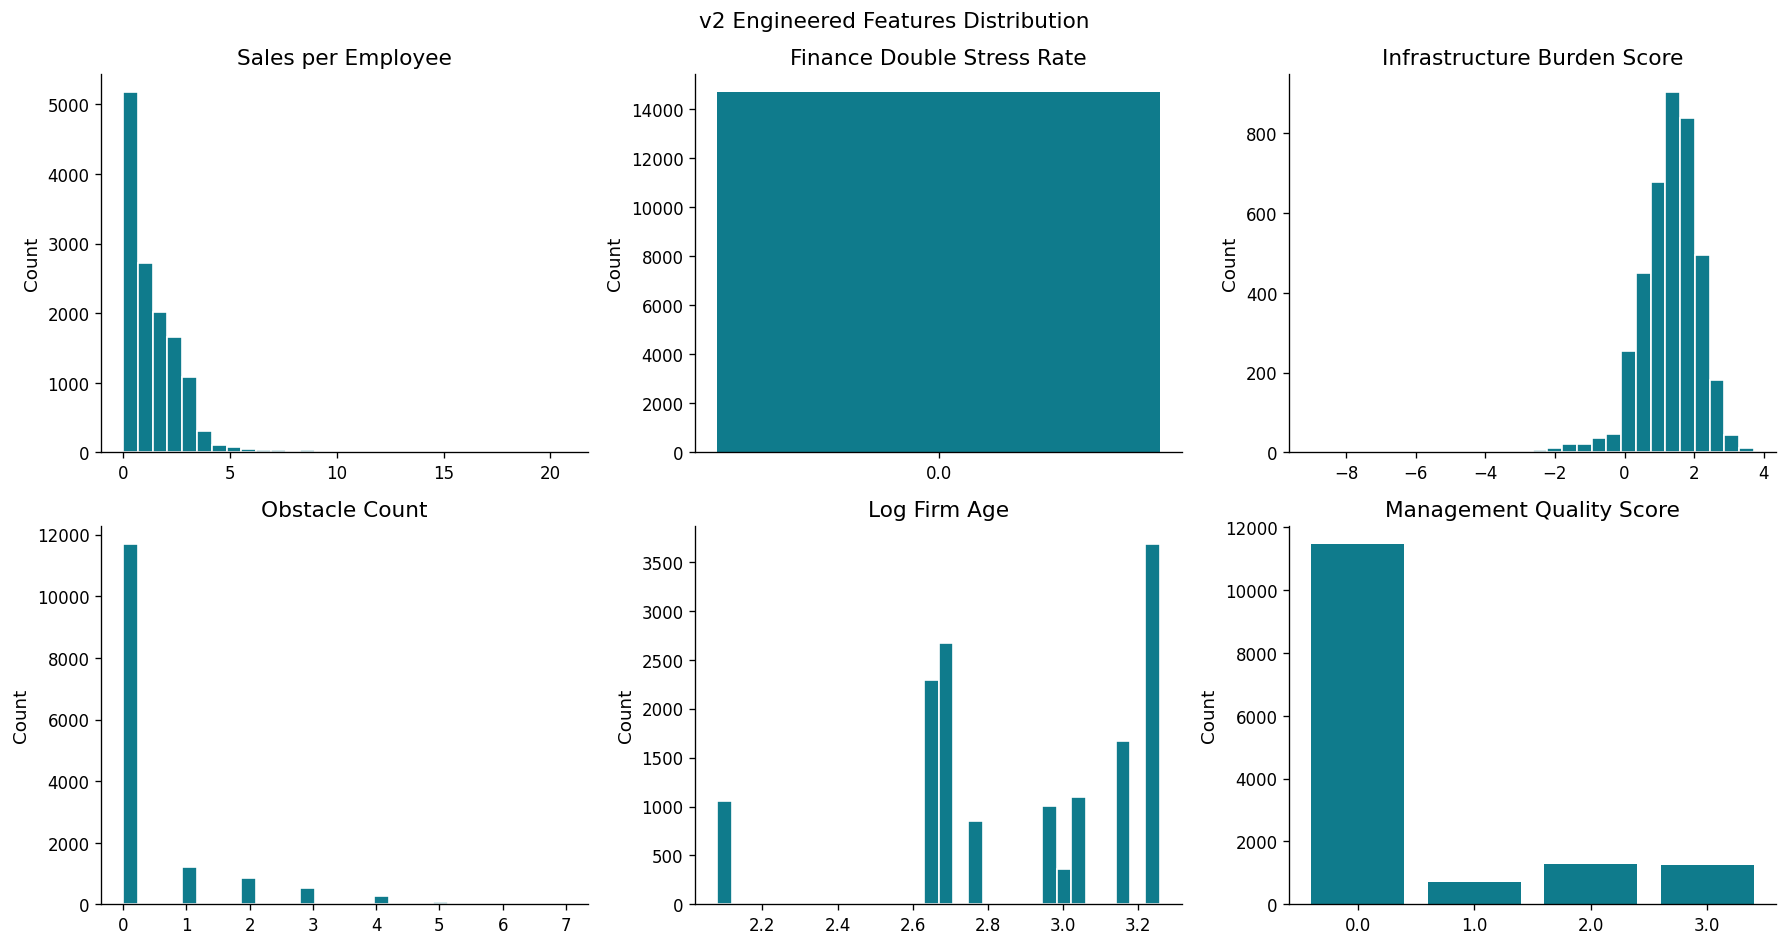

Fig 6 saved.


In [19]:
# Figure 6: New engineered features distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

plot_features = [
    ('sales_per_employee',    'Sales per Employee'),
    ('finance_double_stress', 'Finance Double Stress Rate'),
    ('infra_burden_score',    'Infrastructure Burden Score'),
    ('obstacle_count',        'Obstacle Count'),
    ('log_firm_age',          'Log Firm Age'),
    ('mgmt_quality_score',    'Management Quality Score'),
]

for ax, (feat, title) in zip(axes.flatten(), plot_features):
    if feat in df.columns and df[feat].notna().sum() > 0:
        col_data = df[feat].dropna()
        if col_data.nunique() <= 5:
            counts = col_data.value_counts().sort_index()
            ax.bar(counts.index.astype(str), counts.values, color=PALETTE['highlight'])
        else:
            ax.hist(col_data, bins=30, color=PALETTE['highlight'], edgecolor='white')
        ax.set_title(title)
        ax.set_ylabel('Count')
    else:
        ax.set_visible(False)

plt.suptitle('v2 Engineered Features Distribution', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'fig06_engineered_features.png', bbox_inches='tight')
plt.show()
print('Fig 6 saved.')


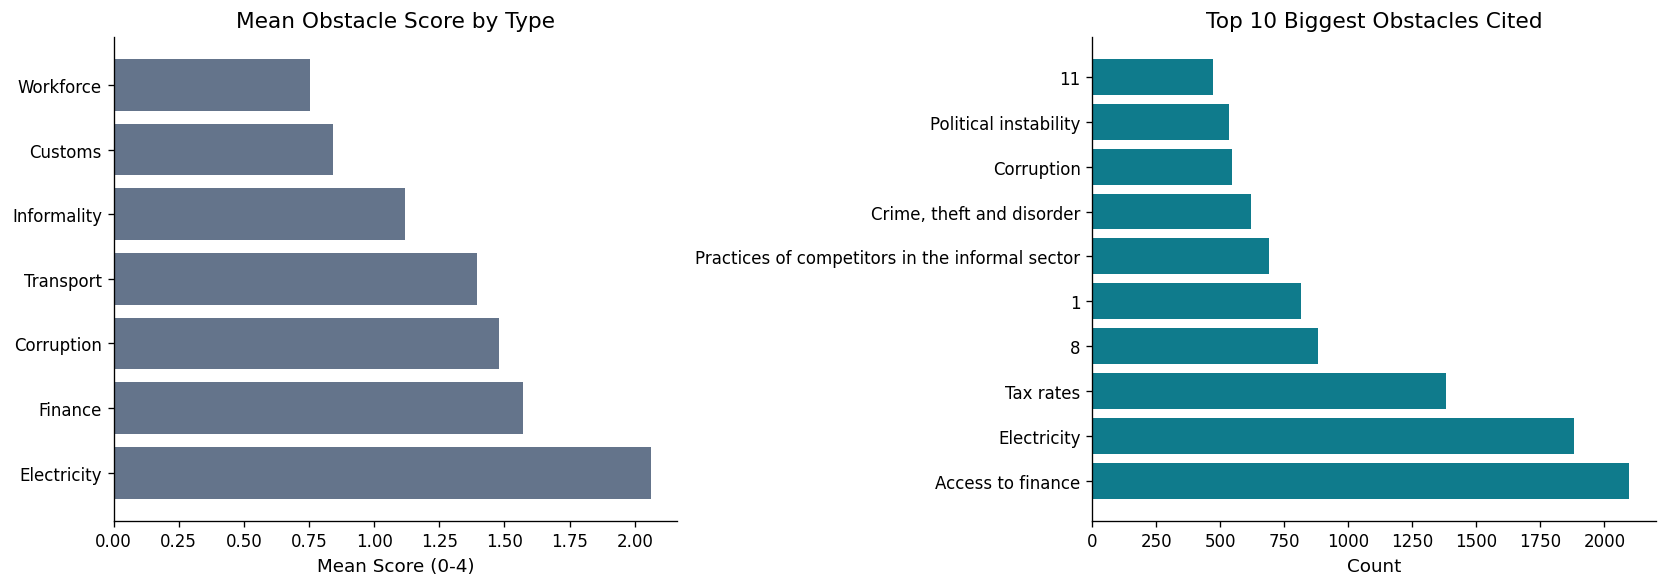

Fig 7 saved.


In [21]:
# Figure 7: Obstacles
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

obstacle_means = {}
for col in obstacle_score_cols:
    name = col.replace('obstacle_', '').replace('_score', '').capitalize()
    obstacle_means[name] = df[col].mean()

sorted_obs = dict(sorted(obstacle_means.items(), key=lambda x: x[1], reverse=True))
axes[0].barh(list(sorted_obs.keys()), list(sorted_obs.values()), color=PALETTE['neutral'])
axes[0].set_title('Mean Obstacle Score by Type')
axes[0].set_xlabel('Mean Score (0-4)')

biggest_obs = df['biggest_obstacle'].value_counts().head(10)
axes[1].barh(biggest_obs.index.astype(str), biggest_obs.values, color=PALETTE['highlight'])
axes[1].set_title('Top 10 Biggest Obstacles Cited')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig(FIGURES_DIR + 'fig07_obstacles.png', bbox_inches='tight')
plt.show()
print('Fig 7 saved.')

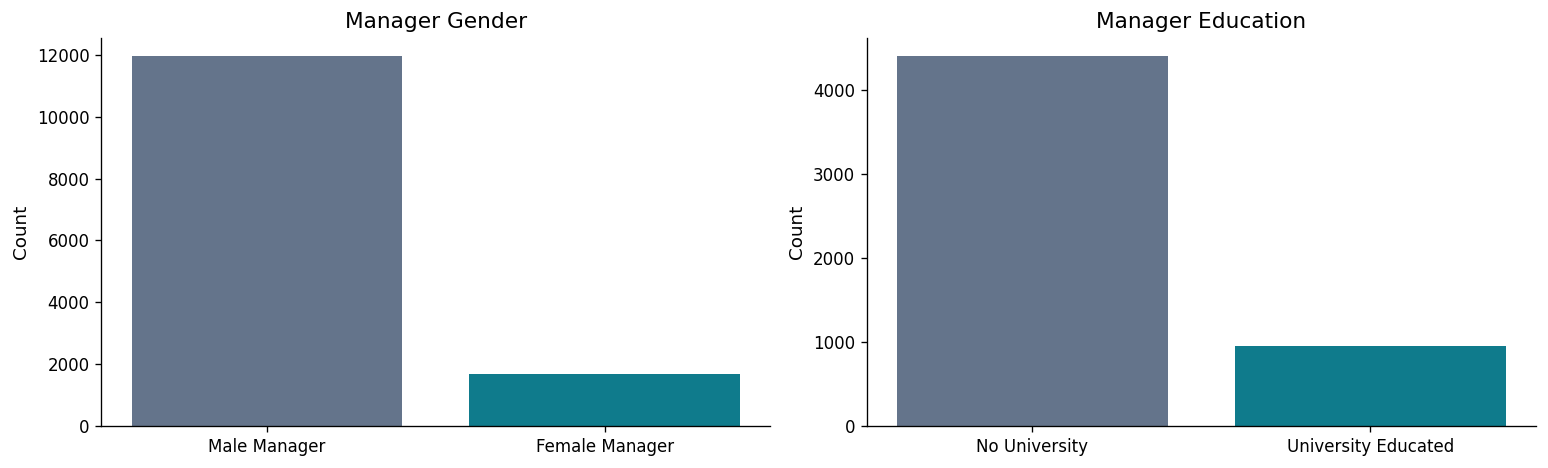

Fig 8 saved.


In [22]:
# Figure 8: Manager characteristics
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

if 'manager_female' in df.columns:
    female_counts = df['manager_female'].value_counts()
    axes[0].bar(['Male Manager', 'Female Manager'],
                [female_counts.get(0, 0), female_counts.get(1, 0)],
                color=[PALETTE['neutral'], PALETTE['highlight']])
    axes[0].set_title('Manager Gender')
    axes[0].set_ylabel('Count')

if 'manager_university' in df.columns:
    edu_counts = df['manager_university'].value_counts()
    axes[1].bar(['No University', 'University Educated'],
                [edu_counts.get(0, 0), edu_counts.get(1, 0)],
                color=[PALETTE['neutral'], PALETTE['highlight']])
    axes[1].set_title('Manager Education')
    axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(FIGURES_DIR + 'fig08_manager_legal.png', bbox_inches='tight')
plt.show()
print('Fig 8 saved.')


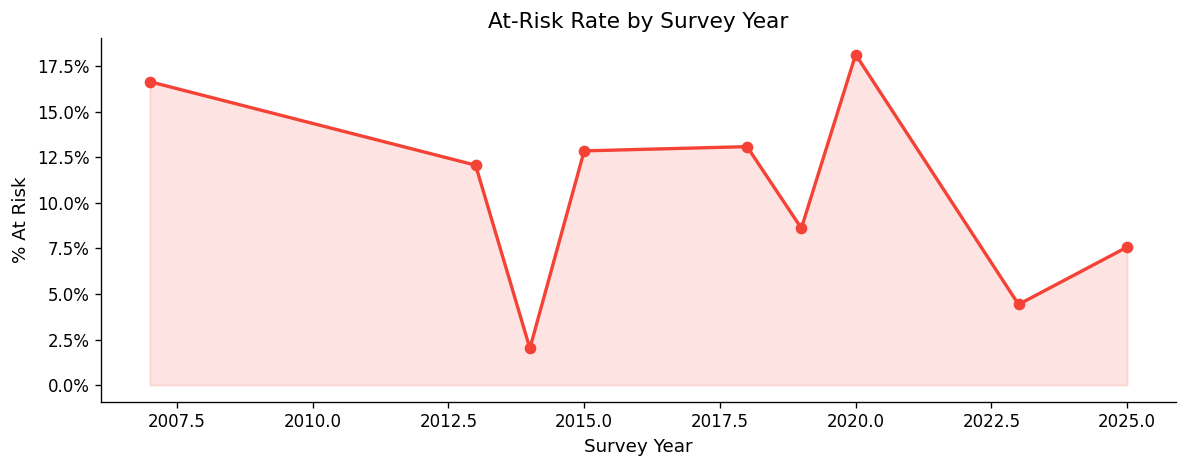

Fig 9 saved.


In [23]:
# Figure 9: Distress trend over time
fig, ax = plt.subplots(figsize=(10, 4))

trend = df.groupby('survey_year')['at_risk'].mean() * 100
ax.plot(trend.index, trend.values, marker='o', color=PALETTE['at_risk'], linewidth=2)
ax.fill_between(trend.index, trend.values, alpha=0.15, color=PALETTE['at_risk'])
ax.set_title('At-Risk Rate by Survey Year')
ax.set_xlabel('Survey Year')
ax.set_ylabel('% At Risk')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig(FIGURES_DIR + 'fig09_distress_trend.png', bbox_inches='tight')
plt.show()
print('Fig 9 saved.')


## 10. Missing Value Imputation

In [24]:
print('=== IMPUTATION ===')

# Capacity utilisation: country-sector median, then global median
df['capacity_util_pct'] = df.groupby(['country', 'broad_sector'])['capacity_util_pct'] \
    .transform(lambda x: x.fillna(x.median()))
df['capacity_util_pct'] = df['capacity_util_pct'].fillna(df['capacity_util_pct'].median())
print(f'Capacity nulls after imputation: {df["capacity_util_pct"].isna().sum()}')

# Log sales: country-sector median, then global median
df['log_sales'] = df.groupby(['country', 'broad_sector'])['log_sales'] \
    .transform(lambda x: x.fillna(x.median()))
df['log_sales'] = df['log_sales'].fillna(df['log_sales'].median())

# Sales per employee: recompute after imputing log_sales
df['sales_per_employee'] = np.where(
    (df['employees_now'].notna()) & (df['employees_now'] > 0),
    df['log_sales'] / df['employees_now'],
    np.nan
)
df['sales_per_employee'] = df['sales_per_employee'].fillna(df['sales_per_employee'].median())

# Infra burden and obstacle count: 0 = no obstacle reported
for col in obstacle_score_cols:
    df[col] = df[col].fillna(0)
if 'infra_burden_score' in df.columns:
    df['infra_burden_score'] = df['infra_burden_score'].fillna(0)
if 'obstacle_count' in df.columns:
    df['obstacle_count'] = df['obstacle_count'].fillna(0)

# Finance percentages: country median, fallback 50
for col in ['pct_internal_finance', 'pct_bank_finance', 'pct_supplier_finance']:
    if col in df.columns:
        df[col] = df.groupby('country')[col].transform(lambda x: x.fillna(x.median()))
        df[col] = df[col].fillna(50.0)

# Management score: 0 if missing
if 'mgmt_quality_score' in df.columns:
    df['mgmt_quality_score'] = df['mgmt_quality_score'].fillna(0)

# Manager female: country mode, fallback 0
if 'manager_female' in df.columns:
    df['manager_female'] = df.groupby('country')['manager_female'] \
        .transform(lambda x: x.fillna(x.mode().iloc[0] if len(x.mode()) > 0 else 0))
    df['manager_female'] = df['manager_female'].fillna(0)

if 'manager_university' in df.columns:
    df['manager_university'] = df['manager_university'].fillna(0)

# size_age_interaction: recompute after firm_size_num imputation
df['firm_size_num'] = df['firm_size_num'].fillna(df['firm_size_num'].median())
df['size_age_interaction'] = df['firm_size_num'] * df['log_firm_age']

print('Imputation complete.')


=== IMPUTATION ===
Capacity nulls after imputation: 0
Imputation complete.


## 11. Final Feature Set & Encoding

### Features deliberately EXCLUDED (distress signal proxies):
- `credit_constrained` — used to build Signal 1
- `employment_growth_rate` — used to build Signal 2
- `emp_growth_available` — flag for Signal 2
- `capacity_util_pct` — used to build Signal 3
- `low_capacity` — binary version of Signal 3

These remain in `df` for EDA reference but are excluded from `ALL_FEATURES_FINAL`.


In [25]:
NUMERIC_FEATURES = [
    # Firm fundamentals
    'firm_size_num',
    'employees_now',
    'log_sales',
    'survey_year',
    # Finance (independent inputs — NOT the signal itself)
    'has_loan_bin',
    'needs_finance_bin',
    'pct_internal_finance',
    'pct_bank_finance',
    'pct_supplier_finance',
    # New v2 engineered features
    'sales_per_employee',
    'finance_double_stress',
    'infra_burden_score',
    'obstacle_count',
    'log_firm_age',
    'size_age_interaction',
    'is_exporter',
    'mgmt_quality_score',
    # Manager characteristics
    'manager_female',
    'manager_university',
]

# ── EXPLICITLY EXCLUDED (would cause leakage) ─────────────────────────────────
LEAKAGE_FEATURES = [
    'credit_constrained',      # = Signal 1
    'employment_growth_rate',  # = Signal 2 raw value
    'emp_growth_available',    # = Signal 2 availability flag
    'capacity_util_pct',       # = Signal 3 raw value
    'low_capacity',            # = Signal 3 binary
    'very_low_capacity',       # = Signal 3 variant
    'severe_credit_constraint',# = Signal 1 variant
    'distress_signal_count',   # = direct target proxy
]

OBSTACLE_FEATURES = [c for c in df.columns
                     if c.endswith('_score') and 'obstacle' in c]

CATEGORICAL_FEATURES = [
    'broad_sector', 'detailed_sector', 'region',
    'legal_status_clean', 'country', 'biggest_obstacle',
]
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in df.columns]

print(f'Numeric features:          {len(NUMERIC_FEATURES)}')
print(f'Obstacle score features:   {len(OBSTACLE_FEATURES)}')
print(f'Categorical (pre-encode):  {len(CATEGORICAL_FEATURES)}')
print()
print('Leakage features EXCLUDED:')
for f in LEAKAGE_FEATURES:
    in_df = '(in df)' if f in df.columns else '(not present)'
    print(f'  ✗  {f:35s} {in_df}')


Numeric features:          19
Obstacle score features:   7
Categorical (pre-encode):  6

Leakage features EXCLUDED:
  ✗  credit_constrained                  (in df)
  ✗  employment_growth_rate              (not present)
  ✗  emp_growth_available                (not present)
  ✗  capacity_util_pct                   (in df)
  ✗  low_capacity                        (in df)
  ✗  very_low_capacity                   (not present)
  ✗  severe_credit_constraint            (not present)
  ✗  distress_signal_count               (in df)


In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in CATEGORICAL_FEATURES:
    if col in df.columns:
        df[col + '_encoded'] = le.fit_transform(
            df[col].astype(str).str.strip().fillna('Unknown')
        )
        print(f'Encoded {col}: {df[col].nunique()} unique values')

ENCODED_CAT_FEATURES = [c + '_encoded' for c in CATEGORICAL_FEATURES if c in df.columns]

ALL_FEATURES_FINAL = (
    [f for f in NUMERIC_FEATURES if f in df.columns] +
    [f for f in OBSTACLE_FEATURES if f in df.columns] +
    ENCODED_CAT_FEATURES
)

# Double-check: ensure no leakage features slipped in
leaked = [f for f in ALL_FEATURES_FINAL if f in LEAKAGE_FEATURES]
if leaked:
    raise ValueError(f'LEAKAGE DETECTED — remove these: {leaked}')

print(f'\n✓ No leakage features detected in ALL_FEATURES_FINAL.')
print(f'Total features for Phase 2: {len(ALL_FEATURES_FINAL)}')


Encoded broad_sector: 12 unique values
Encoded detailed_sector: 69 unique values
Encoded region: 81 unique values
Encoded legal_status_clean: 6 unique values
Encoded country: 8 unique values
Encoded biggest_obstacle: 61 unique values

✓ No leakage features detected in ALL_FEATURES_FINAL.
Total features for Phase 2: 32


In [27]:
TARGET_BINARY = 'at_risk'
TARGET_MULTI  = 'distress_level'

# Final null check — fill any remaining nulls
null_check = df[ALL_FEATURES_FINAL].isnull().sum()
null_remaining = null_check[null_check > 0]

if len(null_remaining) > 0:
    print(f'Filling nulls in {len(null_remaining)} features with median:')
    for col in null_remaining.index:
        if df[col].dtype in ['float64', 'int64', float, int]:
            df[col] = df[col].fillna(df[col].median())
            print(f'  Filled: {col}')
else:
    print('✓ Zero null values in all model features.')

print(f'\nFinal dataset:')
print(f'  Rows:           {len(df):,}')
print(f'  Features:       {len(ALL_FEATURES_FINAL)}')
print(f'  at_risk = 1:    {df[TARGET_BINARY].sum():,} ({df[TARGET_BINARY].mean()*100:.1f}%)')
print(f'  at_risk = 0:    {(df[TARGET_BINARY]==0).sum():,} ({(df[TARGET_BINARY]==0).mean()*100:.1f}%)')
print(f'\n3-class distribution:')
for v, cnt in df[TARGET_MULTI].value_counts().sort_index().items():
    labels_map = {0: 'Stable', 1: 'Moderate Risk', 2: 'High Risk'}
    print(f'  {labels_map[v]}: {cnt:,} ({cnt/len(df)*100:.1f}%)')


Filling nulls in 1 features with median:
  Filled: employees_now

Final dataset:
  Rows:           14,688
  Features:       32
  at_risk = 1:    1,330 (9.1%)
  at_risk = 0:    13,358 (90.9%)

3-class distribution:
  Stable: 6,472 (44.1%)
  Moderate Risk: 6,886 (46.9%)
  High Risk: 1,330 (9.1%)


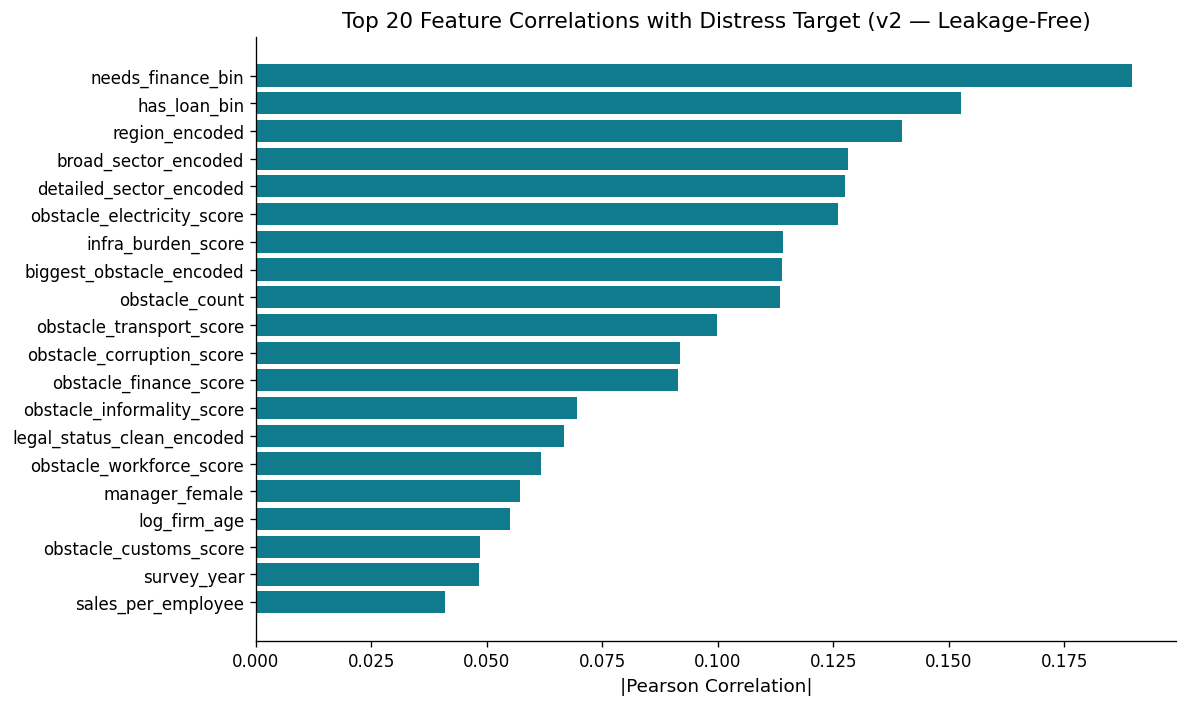

Fig 10 saved.


In [28]:
# Figure 10: Feature correlation with distress target
numeric_for_corr = [f for f in ALL_FEATURES_FINAL
                    if f in df.columns and df[f].dtype in ['float64', 'int64']]

corr_target = df[numeric_for_corr + [TARGET_BINARY]].corr()[TARGET_BINARY] \
    .drop(TARGET_BINARY).abs().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(corr_target.index[::-1], corr_target.values[::-1], color=PALETTE['highlight'])
ax.set_title('Top 20 Feature Correlations with Distress Target (v2 — Leakage-Free)')
ax.set_xlabel('|Pearson Correlation|')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'fig10_feature_correlations_v2.png', bbox_inches='tight')
plt.show()
print('Fig 10 saved.')


## 12. Saving Outputs

In [29]:
MODEL_COLS = (ALL_FEATURES_FINAL +
              [TARGET_BINARY, TARGET_MULTI, 'distress_signal_count',
               'survey_weight', 'country', 'survey_year',
               'broad_sector', 'detailed_sector', 'region',
               'firm_size', 'legal_status_clean'])
MODEL_COLS = list(dict.fromkeys([c for c in MODEL_COLS if c in df.columns]))

output_path = DATA_PROC + 'sme_model_ready_v2.csv'
df[MODEL_COLS].to_csv(output_path, index=False)
print(f'✓ Saved: sme_model_ready_v2.csv')
print(f'  Path:  {output_path}')
print(f'  Shape: {df[MODEL_COLS].shape}')

full_path = DATA_PROC + 'sme_cleaned_full_v2.csv'
df.to_csv(full_path, index=False)
print(f'\n✓ Saved: sme_cleaned_full_v2.csv')


✓ Saved: sme_model_ready_v2.csv
  Path:  /content/drive/MyDrive/Colab Notebooks/SME_Distress_Africa_v2/data/processed/sme_model_ready_v2.csv
  Shape: (14688, 42)

✓ Saved: sme_cleaned_full_v2.csv


In [30]:
phase1_meta = {
    'VERSION':               'v2_leakage_corrected',
    'ALL_FEATURES_FINAL':    ALL_FEATURES_FINAL,
    'CATEGORICAL_FEATURES':  CATEGORICAL_FEATURES,
    'ENCODED_CAT_FEATURES':  ENCODED_CAT_FEATURES,
    'NUMERIC_FEATURES':      [f for f in NUMERIC_FEATURES if f in df.columns],
    'OBSTACLE_FEATURES':     OBSTACLE_FEATURES,
    'LEAKAGE_FEATURES_EXCLUDED': LEAKAGE_FEATURES,
    'TARGET_BINARY':         TARGET_BINARY,
    'TARGET_MULTI':          TARGET_MULTI,
    'COUNTRIES':             df['country'].unique().tolist(),
    'TOTAL_RECORDS':         len(df),
    'AT_RISK_COUNT':         int(df[TARGET_BINARY].sum()),
    'AT_RISK_RATE':          float(df[TARGET_BINARY].mean()),
}

meta_path = DATA_PROC + 'phase1_metadata_v2.json'
with open(meta_path, 'w') as f:
    json.dump(phase1_meta, f, indent=2)

print(f'✓ Saved: phase1_metadata_v2.json')
print(f'\nSummary:')
print(f'  Countries:       {phase1_meta["COUNTRIES"]}')
print(f'  Total firms:     {phase1_meta["TOTAL_RECORDS"]:,}')
print(f'  At-risk rate:    {phase1_meta["AT_RISK_RATE"]*100:.1f}%')
print(f'  Features:        {len(ALL_FEATURES_FINAL)}')
print(f'  Excluded:        {LEAKAGE_FEATURES}')


✓ Saved: phase1_metadata_v2.json

Summary:
  Countries:       ['Kenya', 'Uganda', 'Tanzania', 'Ghana', 'Ethiopia', 'Nigeria', 'Rwanda', 'South Africa']
  Total firms:     14,688
  At-risk rate:    9.1%
  Features:        32
  Excluded:        ['credit_constrained', 'employment_growth_rate', 'emp_growth_available', 'capacity_util_pct', 'low_capacity', 'very_low_capacity', 'severe_credit_constraint', 'distress_signal_count']


In [31]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║         SME DISTRESS — PHASE 1 v2 COMPLETE (LEAKAGE-FREE)          ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Target variable:        distress_level (3-class) + at_risk         ║
║  Signal construction:    3 signals (EXCLUDED from model features)   ║
║  Leakage fix applied:    YES — 6 signal-derived features removed    ║
║  New v2 features added:  9 independent engineered features          ║
║                                                                      ║
║  Outputs saved to:       SME_Distress_Africa_v2/data/processed/     ║
║    sme_model_ready_v2.csv                                           ║
║    sme_cleaned_full_v2.csv                                          ║
║    phase1_metadata_v2.json                                          ║
║                                                                      ║
║  Next step → Phase2_v2 notebook                                     ║
╚══════════════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════════════╗
║         SME DISTRESS — PHASE 1 v2 COMPLETE (LEAKAGE-FREE)          ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Target variable:        distress_level (3-class) + at_risk         ║
║  Signal construction:    3 signals (EXCLUDED from model features)   ║
║  Leakage fix applied:    YES — 6 signal-derived features removed    ║
║  New v2 features added:  9 independent engineered features          ║
║                                                                      ║
║  Outputs saved to:       SME_Distress_Africa_v2/data/processed/     ║
║    sme_model_ready_v2.csv                                           ║
║    sme_cleaned_full_v2.csv                                          ║
║    phase1_metadata_v2.json                                          ║
║                                                           